In [2]:
!git clone https://github.com/Liza228ko/DM2026-Assignment-2.git
%cd DM2026-Assignment-2

fatal: destination path 'DM2026-Assignment-2' already exists and is not an empty directory.
/content/DM2026-Assignment-2


In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import KNNImputer

from model.linear_model import LinearModel
from model.metrics import evaluate_binary_classifier

# Set random seed as instructed
seed = 40
np.random.seed(seed)

In [4]:
# Load the raw dataset using a relative path
file_path = 'data/NYCU_Iris.csv'
df = pd.read_csv(file_path)

# 1. Transform label to bi-class
df['Species'] = df['Species'].astype(str).str.strip()
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

# Separate features and target
feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

X = df[feature_cols].values
y = df['Species'].values

# 2. Train/Test Split FIRST (To prevent Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

# 3. Imputation: Fit on Train, Transform on Train and Test
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# 4. Normalization: Fit on Train, Transform on Train and Test
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing data shape: X={X_test.shape}, y={y_test.shape}")

Training data shape: X=(350, 70), y=(350,)
Testing data shape: X=(150, 70), y=(150,)


50. Training loss: 5.341250038082052, Val loss:6.159898911295359


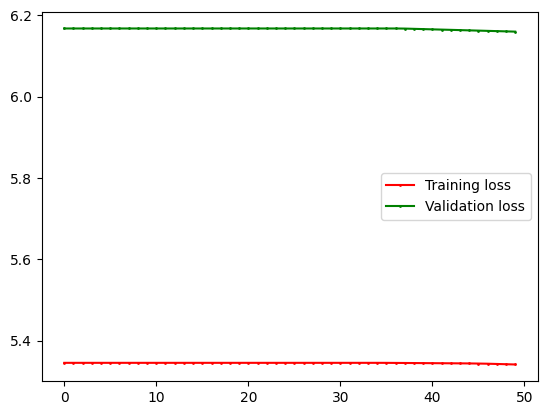

50. Training loss: 5.382943188416434, Val loss:5.330867380765418


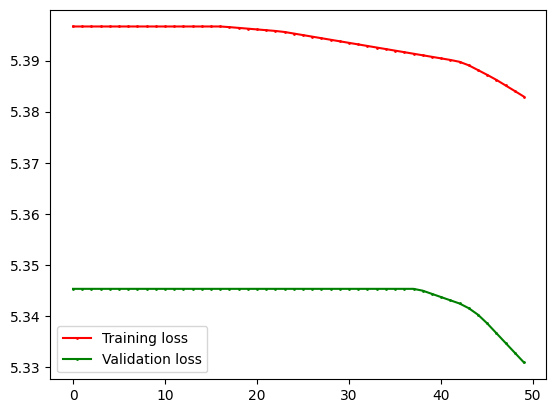

50. Training loss: 5.1911013480741195, Val loss:6.373231060990504


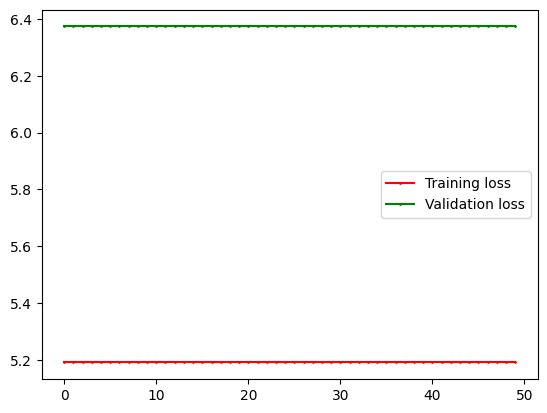

50. Training loss: 5.499483012313176, Val loss:5.962055508671761


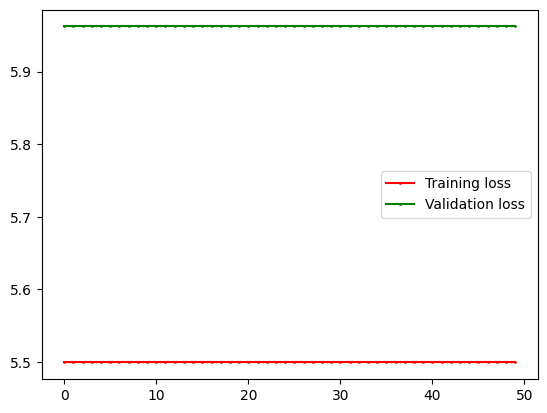

50. Training loss: 5.446953606567339, Val loss:5.135904094567813


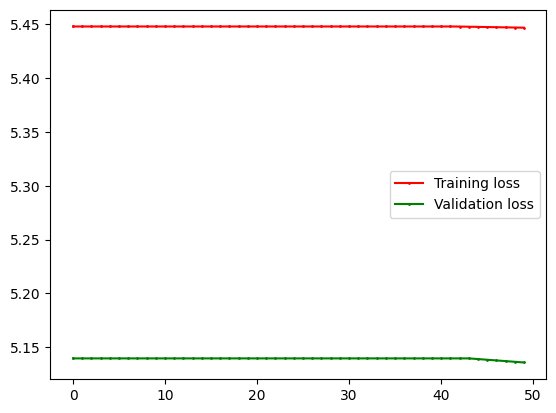

50. Training loss: 5.345292180193646, Val loss:6.167643284831131


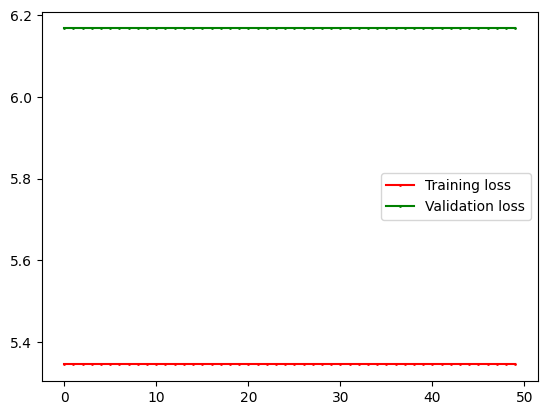

50. Training loss: 5.39668912423349, Val loss:5.345292180193648


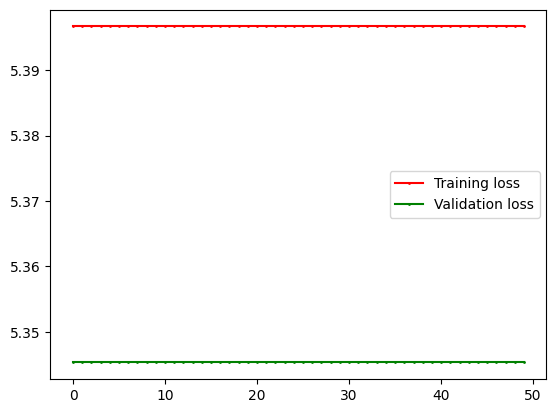

50. Training loss: 5.1911013480741195, Val loss:6.373231060990504


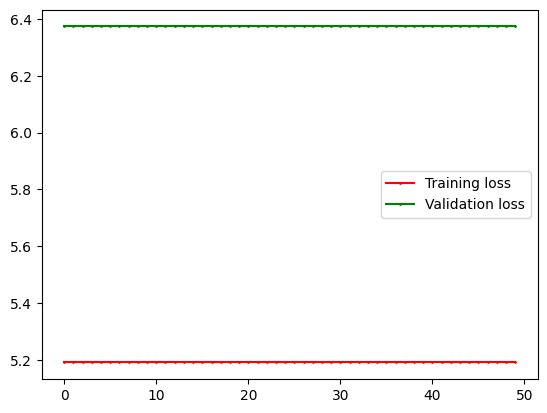

50. Training loss: 5.499483012313176, Val loss:5.962055508671761


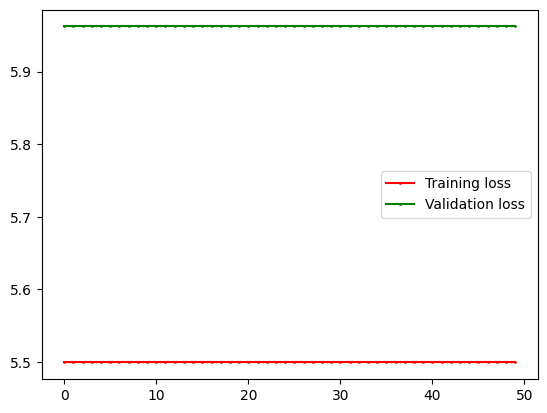

50. Training loss: 5.448086068273333, Val loss:5.139704404034276


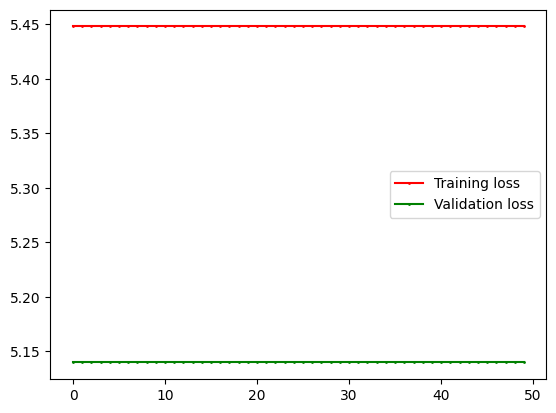

50. Training loss: 5.345292180193646, Val loss:6.167643284831131


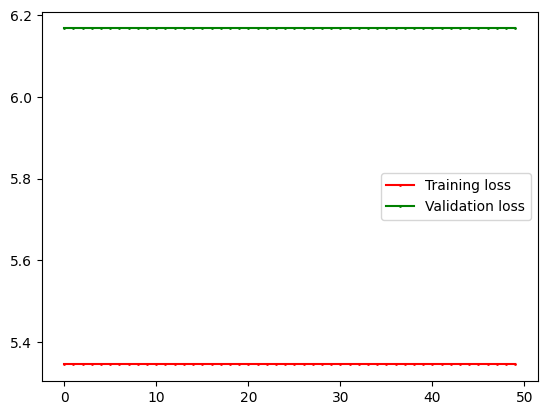

50. Training loss: 5.3962669415120805, Val loss:5.345292180193648


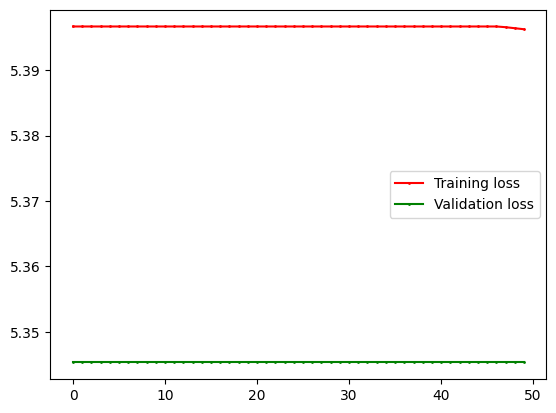

50. Training loss: 5.19098497140037, Val loss:6.373231060990504


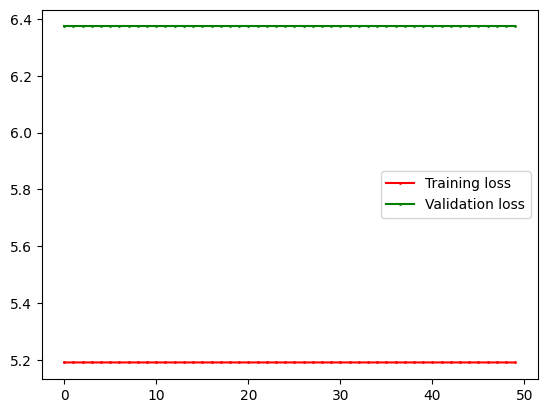

50. Training loss: 5.4518541467161095, Val loss:5.957562629424713


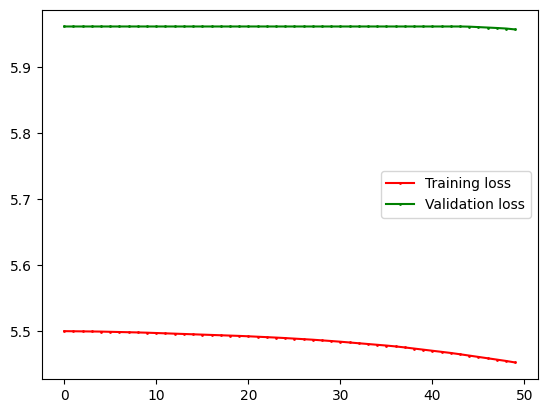

50. Training loss: 5.448086068273333, Val loss:5.139704404034276


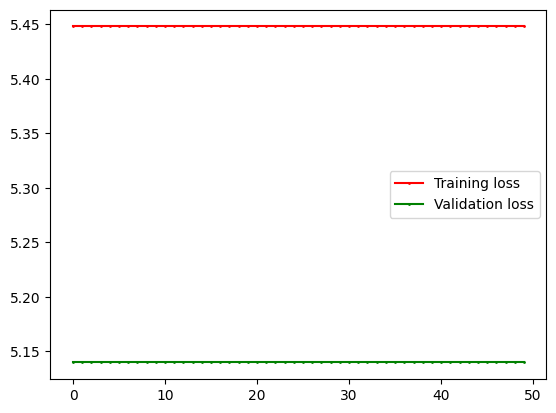

50. Training loss: 5.345292180193646, Val loss:6.167643284831131


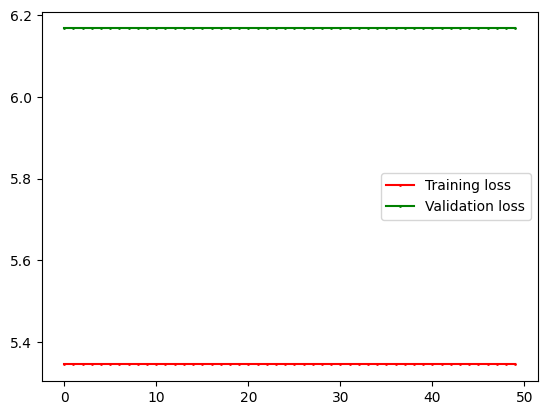

50. Training loss: 5.392003316834413, Val loss:5.343848115154747


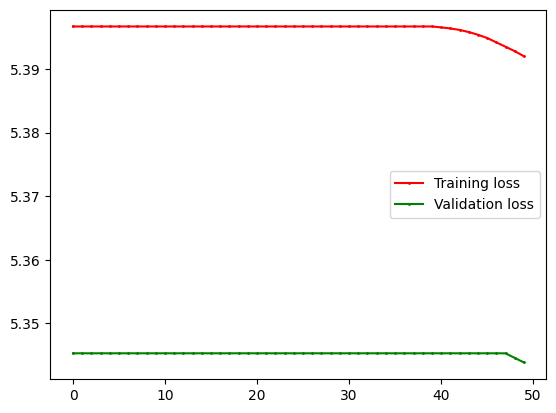

50. Training loss: 5.1911013480741195, Val loss:6.373231060990504


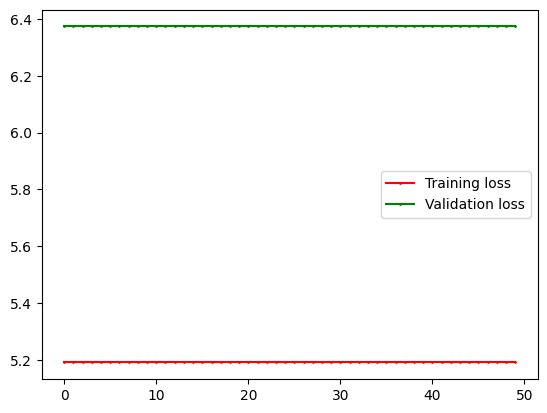

50. Training loss: 5.499483012313176, Val loss:5.962055508671761


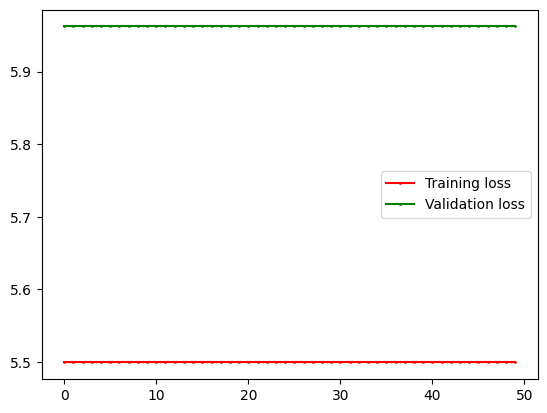

50. Training loss: 5.448086068273333, Val loss:5.139704404034276


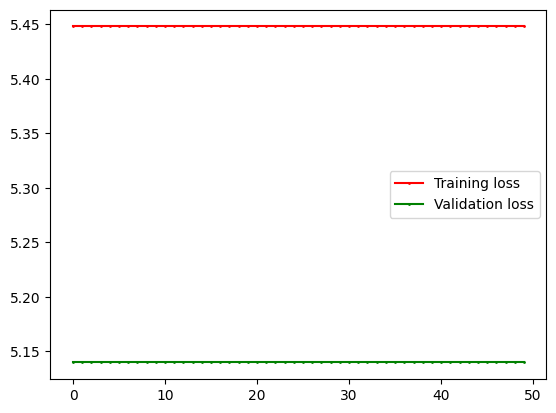

50. Training loss: 5.336120090686892, Val loss:6.159602924349805


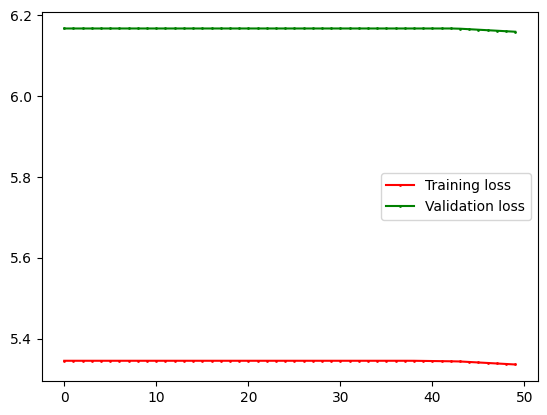

50. Training loss: 5.319006037570084, Val loss:5.260610047912187


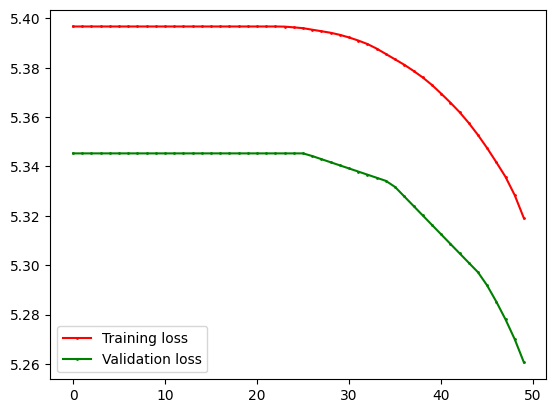

50. Training loss: 5.147410121531392, Val loss:6.3291784217271285


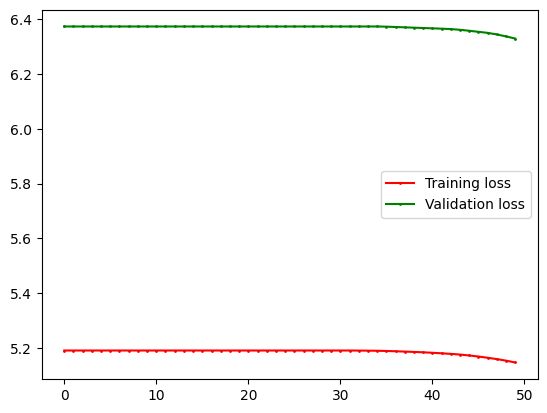

50. Training loss: 5.454538636848517, Val loss:5.956750431192099


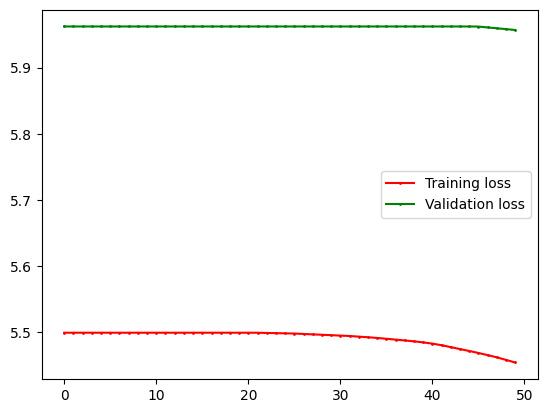

50. Training loss: 5.303005117435299, Val loss:5.006134329577065


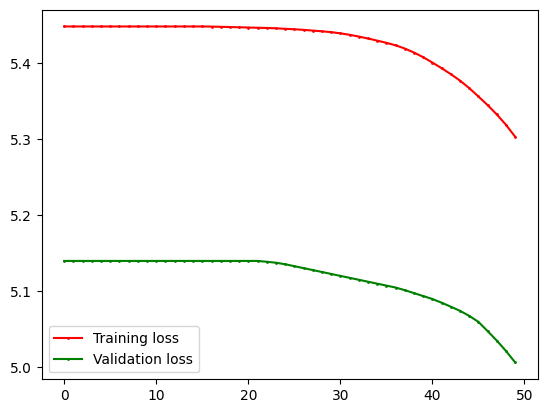

50. Training loss: 5.345292180193646, Val loss:6.167643284831131


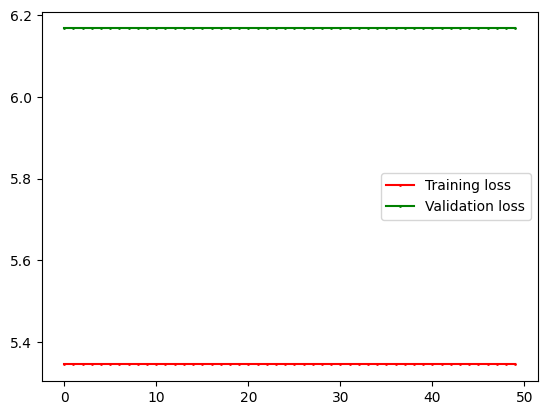

50. Training loss: 5.218872811698048, Val loss:5.195952213820129


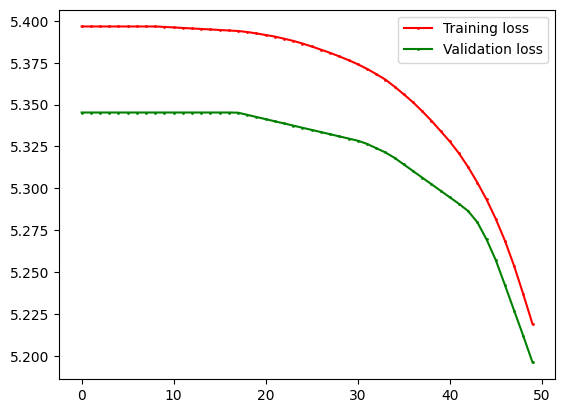

50. Training loss: 5.001091951108132, Val loss:6.147947372427497


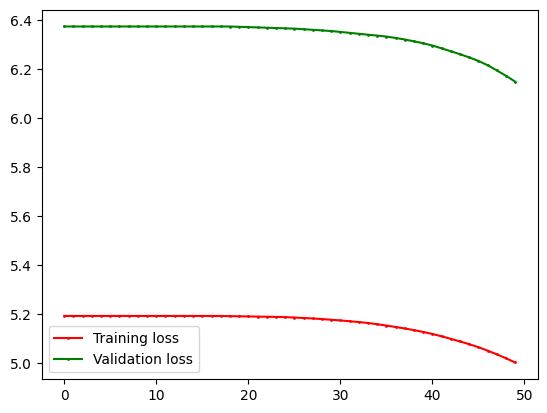

50. Training loss: 5.429232300294426, Val loss:5.918038185454323


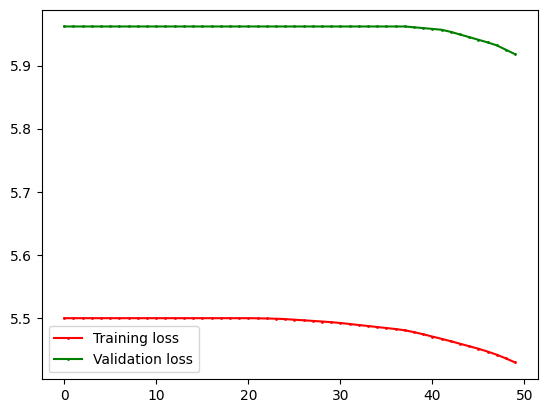

50. Training loss: 5.430626369375284, Val loss:5.1046540112293775


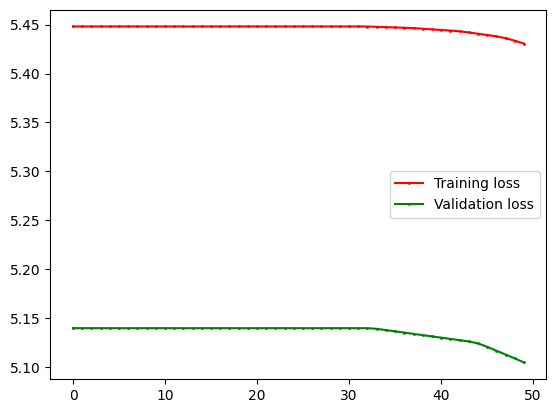

50. Training loss: 5.333406210112535, Val loss:6.1506382580338155


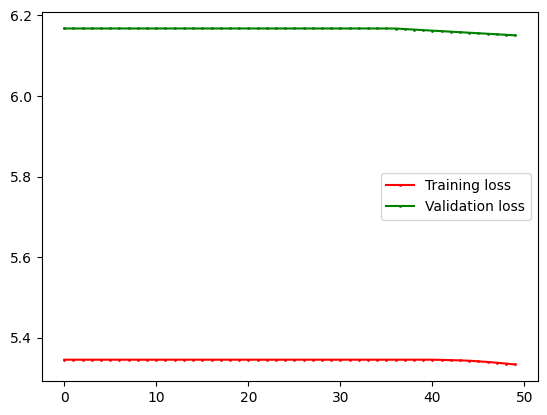

50. Training loss: 5.363011590402623, Val loss:5.311234966235442


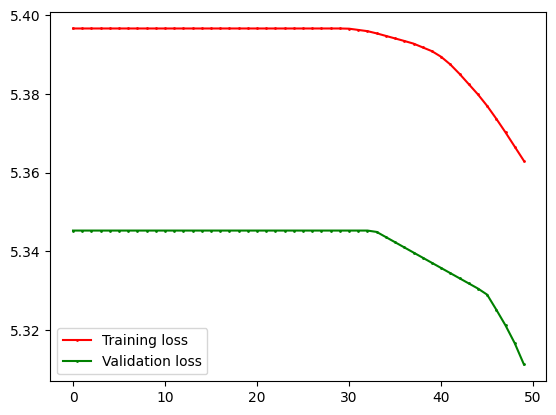

50. Training loss: 5.184681570432348, Val loss:6.359904497564508


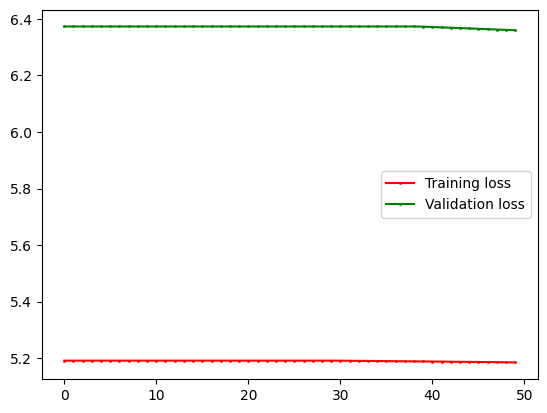

50. Training loss: 5.265894500897951, Val loss:5.754190955297522


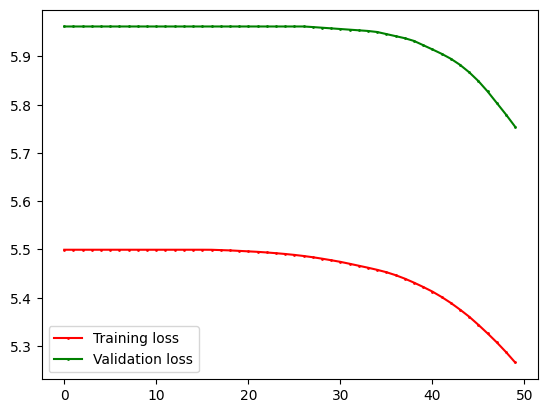

50. Training loss: 5.160691246739174, Val loss:4.779300155940324


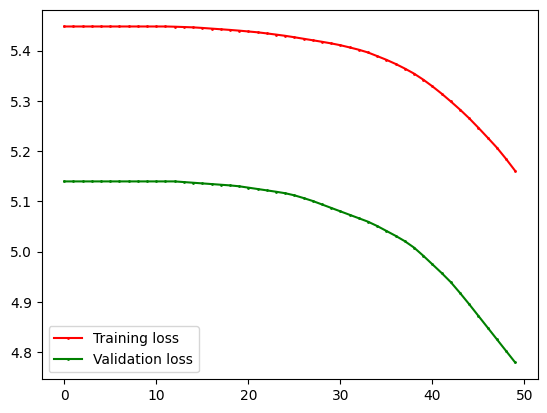

50. Training loss: 5.345292180193646, Val loss:6.167643284831131


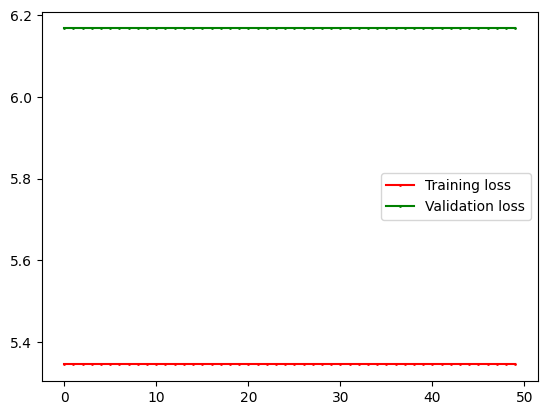

50. Training loss: 5.352576855987431, Val loss:5.294795848157385


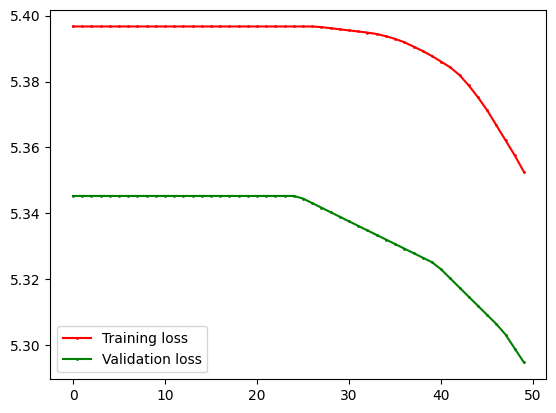

50. Training loss: 5.1911013480741195, Val loss:6.373231060990504


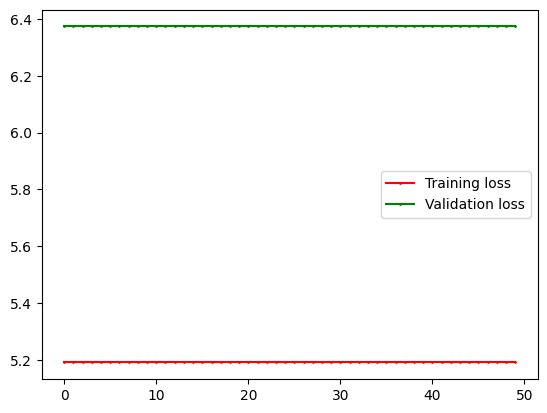

50. Training loss: 5.267775267123639, Val loss:5.796012801983538


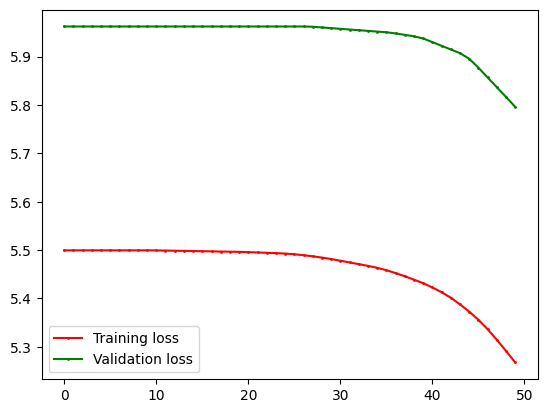

50. Training loss: 5.427908707857952, Val loss:5.125829791484949


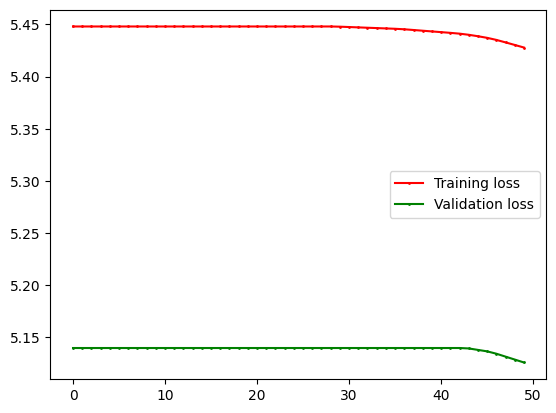

50. Training loss: 0.6669959760982677, Val loss:0.7184265638441748


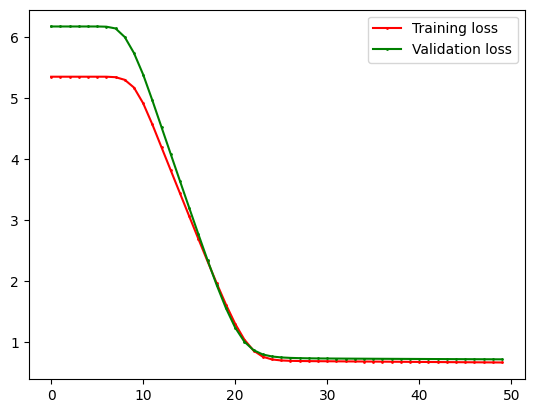

50. Training loss: 0.6917776153278538, Val loss:0.7049606022679146


In [ ]:
# Import the required mathematical functions for the model
from model.metrics import logloss
from model.activations import sigmoid
from model.gradients import logloss_sigmoid_grad

# 1(a). K-fold Cross-Validation
learning_rates = [0.005, 0.01, 0.1, 0.5]
reg_lambdas = [1.0, 2.0, 4.0, 8.0]

# Setup KFold exactly as required
kf = KFold(n_splits=5, shuffle=True, random_state=seed)

# Matrix to store average accuracies for the 4x4 table
results_matrix = np.zeros((len(learning_rates), len(reg_lambdas)))

# Dictionary to keep track of scores for 1(b)
hyperparameter_scores = {}

for i, lr in enumerate(learning_rates):
    for j, reg in enumerate(reg_lambdas):
        # Configure LinearModel with required functions and L2 Regularization
        # FIXED: Added loss_fn, act_fn, and grad_fn
        model = LinearModel(
            dim=X_train.shape[1],
            lr=lr,
            reg_lambda=reg,
            reg_type='l2',
            loss_fn=logloss,
            act_fn=sigmoid,
            grad_fn=logloss_sigmoid_grad
        )

        # Use cross_val_score to handle the folding and internal validation automatically
        scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')

        # Calculate the average accuracy across the 5 folds
        avg_accuracy = np.mean(scores)

        # Store results
        results_matrix[i, j] = avg_accuracy
        hyperparameter_scores[(lr, reg)] = avg_accuracy

# Format and display the 4x4 table using pandas
table_df = pd.DataFrame(
    results_matrix,
    index=[f"LR: {lr}" for lr in learning_rates],
    columns=[f"Lambda: {reg}" for reg in reg_lambdas]
)

print("--- 1(a): 5-Fold Cross Validation Average Accuracies ---")
display(table_df)

In [ ]:
# 1(b). Select the top two hyperparameter settings
sorted_scores = sorted(hyperparameter_scores.items(), key=lambda item: item[1], reverse=True)
top_two_settings = sorted_scores[:2]

print("--- Top Two Hyperparameter Combinations ---")
for rank, (params, score) in enumerate(top_two_settings, 1):
    print(f"Rank {rank}: Learning Rate = {params[0]}, Lambda = {params[1]} (CV Accuracy: {score:.4f})")

print("\n--- Evaluating Top Two Models on Unseen Testing Data ---")

for rank, (params, _) in enumerate(top_two_settings, 1):
    lr, reg = params
    print(f"\nEvaluating Rank {rank} Model [LR: {lr}, Lambda: {reg}]:")

    # Instantiate the model with the top hyperparameters
    # FIXED: Added loss_fn, act_fn, and grad_fn
    final_model = LinearModel(
        dim=X_train.shape[1],
        lr=lr,
        reg_lambda=reg,
        reg_type='l2',
        loss_fn=logloss,
        act_fn=sigmoid,
        grad_fn=logloss_sigmoid_grad
    )

    # Fit on the ENTIRE training set
    final_model.fit(X_train, y_train)

    # Predict on the unseen testing set
    y_pred = final_model.predict(X_test)

    # Report testing results using the provided evaluation function
    evaluate_binary_classifier(y_test, y_pred)